In [3]:
#Outcome: Visualize the data from Toronto Awarded Contracts

import numpy as np
import pandas as pd

import re

import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
np.random.seed(42)

In [5]:
#Retrive data

df = pd.read_csv("./Awarded Contracts.csv")
df.head(2)

,_id,unique_id,Document Number,RFx (Solicitation) Type,High Level Category,Successful Supplier,Awarded Amount,Award Date,Division,Buyer Name,Buyer Email,Buyer Phone Number,Solicitation Document Description
0,1,84b49458-9376-4812-9a7b-79dda5ce4cf2_1,Doc3512316731,RFSQ,Construction Services,Trans Canada Construction,0,2023-05-08,Corporate Real Estate Management,Ryan Phelan,Ryan.Phelan@toronto.ca,4163974814,"General Contractors for New Construction, Reno..."
1,2,84b49458-9376-4812-9a7b-79dda5ce4cf2_2,Doc3512316731,RFSQ,Construction Services,Anacond Contracting,0,2023-05-08,Corporate Real Estate Management,Ryan Phelan,Ryan.Phelan@toronto.ca,4163974814,"General Contractors for New Construction, Reno..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842 entries, 0 to 841
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   _id                                842 non-null    int64 
 1   unique_id                          842 non-null    object
 2   Document Number                    842 non-null    object
 3   RFx (Solicitation) Type            842 non-null    object
 4   High Level Category                842 non-null    object
 5   Successful Supplier                839 non-null    object
 6   Awarded Amount                     842 non-null    object
 7   Award Date                         841 non-null    object
 8   Division                           821 non-null    object
 9   Buyer Name                         842 non-null    object
 10  Buyer Email                        842 non-null    object
 11  Buyer Phone Number                 842 non-null    object
 12  Solicita

In [7]:
df.dropna()

,_id,unique_id,Document Number,RFx (Solicitation) Type,High Level Category,Successful Supplier,Awarded Amount,Award Date,Division,Buyer Name,Buyer Email,Buyer Phone Number,Solicitation Document Description
0,1,84b49458-9376-4812-9a7b-79dda5ce4cf2_1,Doc3512316731,RFSQ,Construction Services,Trans Canada Construction,0,2023-05-08,Corporate Real Estate Management,Ryan Phelan,Ryan.Phelan@toronto.ca,4163974814,"General Contractors for New Construction, Reno..."
1,2,84b49458-9376-4812-9a7b-79dda5ce4cf2_2,Doc3512316731,RFSQ,Construction Services,Anacond Contracting,0,2023-05-08,Corporate Real Estate Management,Ryan Phelan,Ryan.Phelan@toronto.ca,4163974814,"General Contractors for New Construction, Reno..."
2,3,84b49458-9376-4812-9a7b-79dda5ce4cf2_3,Doc3512316731,RFSQ,Construction Services,Area Construction,0,2023-05-08,Corporate Real Estate Management,Ryan Phelan,Ryan.Phelan@toronto.ca,4163974814,"General Contractors for New Construction, Reno..."
3,4,84b49458-9376-4812-9a7b-79dda5ce4cf2_4,Doc3512316731,RFSQ,Construction Services,BDA Inc,0,2023-05-08,Corporate Real Estate Management,Ryan Phelan,Ryan.Phelan@toronto.ca,4163974814,"General Contractors for New Construction, Reno..."
4,5,84b49458-9376-4812-9a7b-79dda5ce4cf2_5,Doc3512316731,RFSQ,Construction Services,Dole Contracting,0,2023-05-08,Corporate Real Estate Management,Ryan Phelan,Ryan.Phelan@toronto.ca,4163974814,"General Contractors for New Construction, Reno..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
837,838,7412168a-7ea0-494b-ad44-6867c7478b93_1,Doc4587869729,RFQ,Goods and Services,Five Star Enterprises of Canada Ltd.,"$76,869.90",2025-02-21,Purchasing & Materials Management,Jeffrey San Miguel,Jeffrey.SanMiguel@toronto.ca,4163974825,The non-exclusive supply and delivery of safet...
838,839,8d7ad091-1619-4943-9832-56e5c5e8daf4_1,Doc4726186752,RFP,Professional Services,Parsons Inc.,"12,157,623.60",2025-01-15,Engineering & Construction Services,Penny Petridis,Penny.Petridis@toronto.ca,4163948127,Request for Proposals for Engineering Services...
839,840,10b9f552-c387-4ac1-9e26-1dec620d94e5_1,Doc4574804004,RFT,Construction Services,KUDLAK-BAIRD 1982 LIMITED,"394,838.00",2024-09-13,Corporate Real Estate Management,Karen Peralta,Karen.Peralta@toronto.ca,4163385606,This Request for Tenders is an invitation by t...
840,841,baf3ecfb-01aa-452c-9a1c-09f7ca0cc25b_1,Doc4207675073,RFP,Goods and Services,INTERNATIONAL NAME PLATE SUPPLIES LIMITED,"156,490.75",2024-06-09,Corporate Real Estate Management,Karen Peralta,Karen.Peralta@toronto.ca,4163385606,Request for Quotations for the Union Station S...


In [8]:

price_col = "Awarded Amount"
if price_col in df.columns:
    df[price_col] = (
        df[price_col]
        .astype(str)
        .replace(r'[\$,]', '', regex=True)
        .replace(r'[^0-9.\-]+', '', regex=True)
        .replace(r'\s+', '', regex=True)
        .replace('', '0', regex=False)
        .astype(float)
    )

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842 entries, 0 to 841
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   _id                                842 non-null    int64  
 1   unique_id                          842 non-null    object 
 2   Document Number                    842 non-null    object 
 3   RFx (Solicitation) Type            842 non-null    object 
 4   High Level Category                842 non-null    object 
 5   Successful Supplier                839 non-null    object 
 6   Awarded Amount                     842 non-null    float64
 7   Award Date                         841 non-null    object 
 8   Division                           821 non-null    object 
 9   Buyer Name                         842 non-null    object 
 10  Buyer Email                        842 non-null    object 
 11  Buyer Phone Number                 842 non-null    object 

In [10]:
# Data Assumptions and Limitation

# Records that have a dollar amount of 0 in the Contract Value or Award Value fields may be the result of solicitations 
# (ie: Requests for Supplier Qualifications) being used to obtain a pre-qualified list of suppliers to use for future solicitations. 
# No dollar amounts are immediately associated with these types of solicitations

# The objective of this is to vsualize the most accurate information about the bidding process.


In [11]:
# Categorical Variables
#   1.  "RFx (Solicitation) Type"
#   2.  "High Level Category"
#   3.  "Successful Supplier"
#   4.  "Award Date"
#   5.  "Division"

# Numeric Variables
#   1.  "_id"
#   2.  "Awarded Amount"


In [12]:
# Number Contracts by Month & Year
# High Level Category vs Price
# Price by Month & Year
# 

In [13]:
categorial_variables = ["RFx (Solicitation) Type",
                     "High Level Category",
                     "Successful Supplier",
                     "Award Date",
                     "Division"
                     ]

numeric_variables = ["_id",
                     "Awarded Amount"
                     ]

In [14]:
df_zero_dollar = df[df["Awarded Amount"] == 0.0]

df_zero_dollar.head(2)

,_id,unique_id,Document Number,RFx (Solicitation) Type,High Level Category,Successful Supplier,Awarded Amount,Award Date,Division,Buyer Name,Buyer Email,Buyer Phone Number,Solicitation Document Description
0,1,84b49458-9376-4812-9a7b-79dda5ce4cf2_1,Doc3512316731,RFSQ,Construction Services,Trans Canada Construction,0.0,2023-05-08,Corporate Real Estate Management,Ryan Phelan,Ryan.Phelan@toronto.ca,4163974814,"General Contractors for New Construction, Reno..."
1,2,84b49458-9376-4812-9a7b-79dda5ce4cf2_2,Doc3512316731,RFSQ,Construction Services,Anacond Contracting,0.0,2023-05-08,Corporate Real Estate Management,Ryan Phelan,Ryan.Phelan@toronto.ca,4163974814,"General Contractors for New Construction, Reno..."


In [15]:
df_price = df[df["Awarded Amount"] != 0.0]

df_price.head(2)

,_id,unique_id,Document Number,RFx (Solicitation) Type,High Level Category,Successful Supplier,Awarded Amount,Award Date,Division,Buyer Name,Buyer Email,Buyer Phone Number,Solicitation Document Description
14,15,b347eaf5-9744-44b3-a5d2-a2f9a8a09395_1,Doc3718447124,RFQ,Goods and Services,Asplundh Canada ULC,5952260.16,2023-07-11,"Parks, Forestry & Recreation",Ryan Phelan,Ryan.Phelan@toronto.ca,4163974814,This Request for Proposals (RFP) is an invitat...
15,16,b347eaf5-9744-44b3-a5d2-a2f9a8a09395_2,Doc3718447124,RFQ,Goods and Services,Diamond Tree Care & Consulting Inc.,4941090.00,2023-07-11,"Parks, Forestry & Recreation",Ryan Phelan,Ryan.Phelan@toronto.ca,4163974814,This Request for Proposals (RFP) is an invitat...


In [16]:
df_price["Award Date"] = pd.to_datetime(df_price["Award Date"])

C:\Users\jcp_2\AppData\Local\Temp\ipykernel_31380\2562162291.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_price["Award Date"] = pd.to_datetime(df_price["Award Date"])


In [17]:
categorical_var_unique ={}
for variable in categorial_variables:
    categorical_var_unique[variable] = df_price[variable].unique()

In [18]:
grouped_division_supplier = df_price.groupby(["High Level Category", "Successful Supplier"])["Awarded Amount"].sum().sort_values(ascending=False)
print(grouped_division_supplier)

High Level Category    Successful Supplier             
Construction Services  D CRUPI & SONS LIMITED              1.174845e+08
                       DAMEN SHIPBUILDING 5 B.V.           9.056919e+07
                       GIP PAVING INC                      8.910128e+07
                       BENNETT MECHANICAL INSTALLATIONS    8.775788e+07
                       Bennett Mechanical Installations    7.727880e+07
                                                               ...     
Goods and Services     PRICEWATERHOUSECOOPERS LLP          1.000000e-02
                       DELOITTE                            1.000000e-02
                       SLALOM CONSULTING ULC               1.000000e-02
                       CARAHSOFT TECHNOLOGY CORP           1.000000e-02
                       CATALYST CONSULTING GROUP           1.000000e-02
Name: Awarded Amount, Length: 600, dtype: float64


In [19]:

for variable in categorial_variables:
    x_variable = df_price[[variable]].values
    y = df_price["Awarded Amount"].values

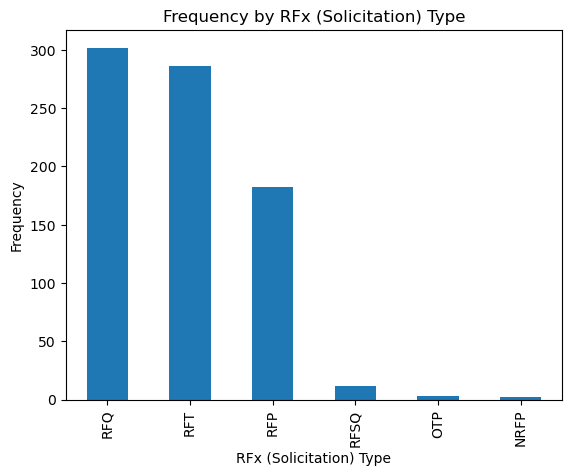

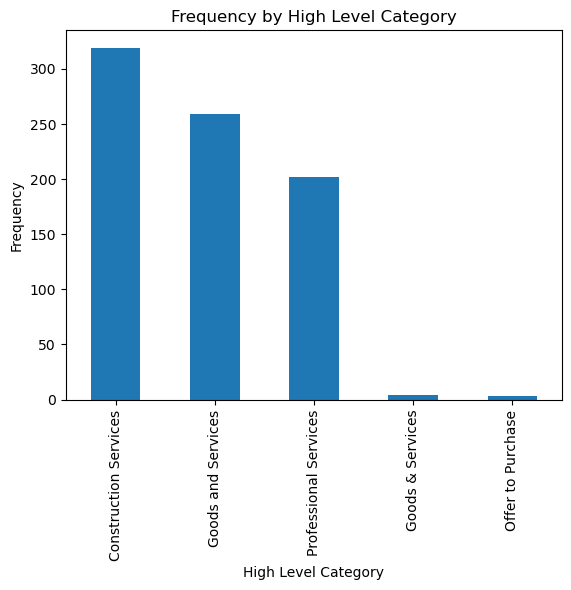

In [20]:
cat_to_viz = ["RFx (Solicitation) Type",
              "High Level Category"]

for variable in cat_to_viz:

    df_price[variable].value_counts().plot(kind="bar")
    
    # Add labels and title
    plt.xlabel(variable)
    plt.ylabel('Frequency')
    plt.title(f'Frequency by {variable}')    

    # Show the Plot
    plt.show()
    

In [21]:
df_price["Clean Supplier"] = (
    df["Successful Supplier"]
    .str.lower()                            # convert to lowercase
    .str.strip()                            # strip leading/trailing spaces
    .str.replace(r"[.,']", "", regex=True)  # remove periods, commas, apostrophes
)

C:\Users\jcp_2\AppData\Local\Temp\ipykernel_31380\3467622676.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_price["Clean Supplier"] = (


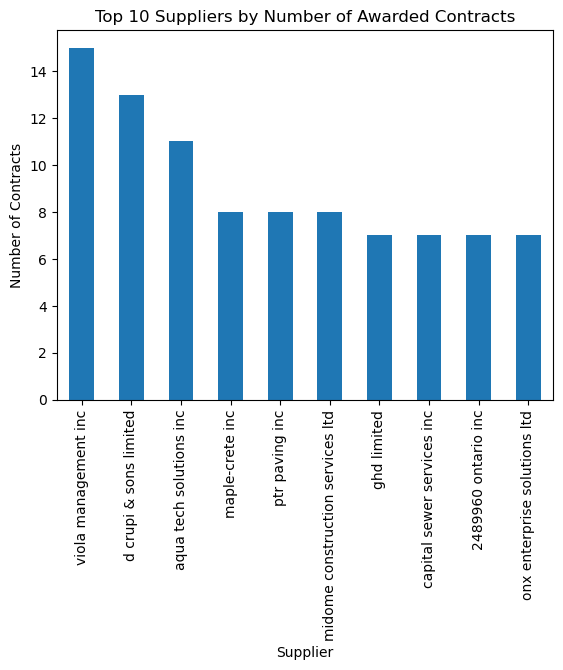

In [22]:
top_suppliers_count = (
    df_price.groupby("Clean Supplier")["_id"].count()  
    .sort_values(ascending=False)
    .head(10)
)

top_suppliers_count.plot(kind="bar")
plt.title("Top 10 Suppliers by Number of Awarded Contracts")
plt.xlabel("Supplier")
plt.ylabel("Number of Contracts")
plt.show()

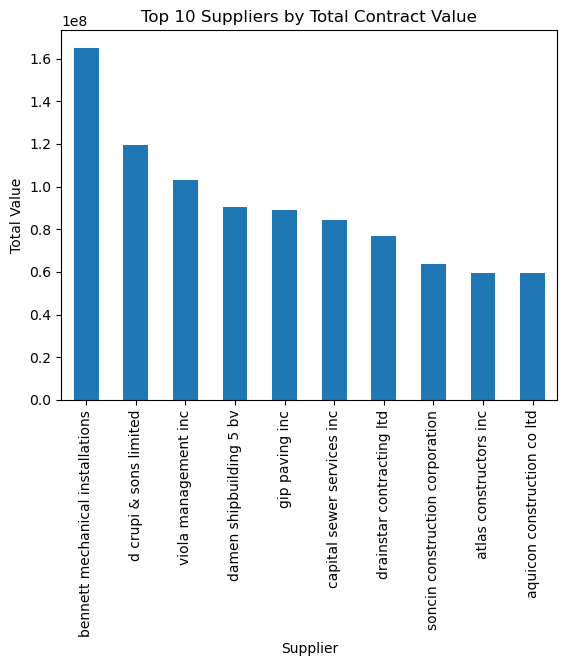

In [23]:
top_suppliers_amount = (
    df_price.groupby("Clean Supplier")["Awarded Amount"].sum()
    .sort_values(ascending=False)
    .head(10)
)

top_suppliers_amount.plot(kind="bar")
plt.title("Top 10 Suppliers by Total Contract Value")
plt.xlabel("Supplier")
plt.ylabel("Total Value")
plt.show()

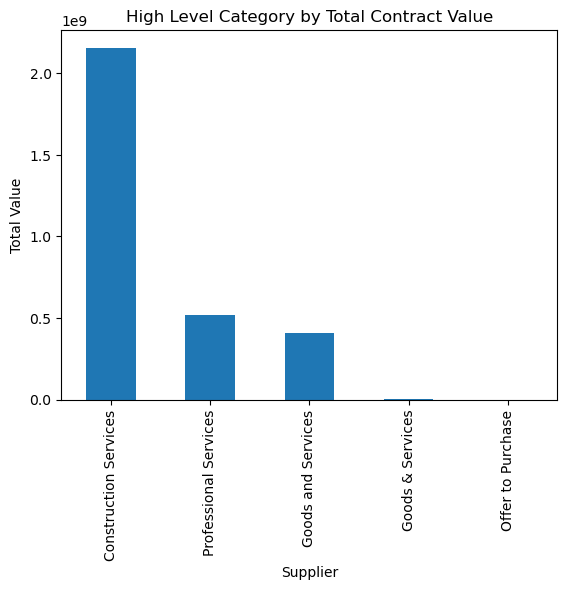

In [24]:
top_suppliers_amount = (
    df_price.groupby("High Level Category")["Awarded Amount"].sum()
    .sort_values(ascending=False)
    .head(10)
)

top_suppliers_amount.plot(kind="bar")
plt.title("High Level Category by Total Contract Value")
plt.xlabel("Supplier")
plt.ylabel("Total Value")
plt.show()

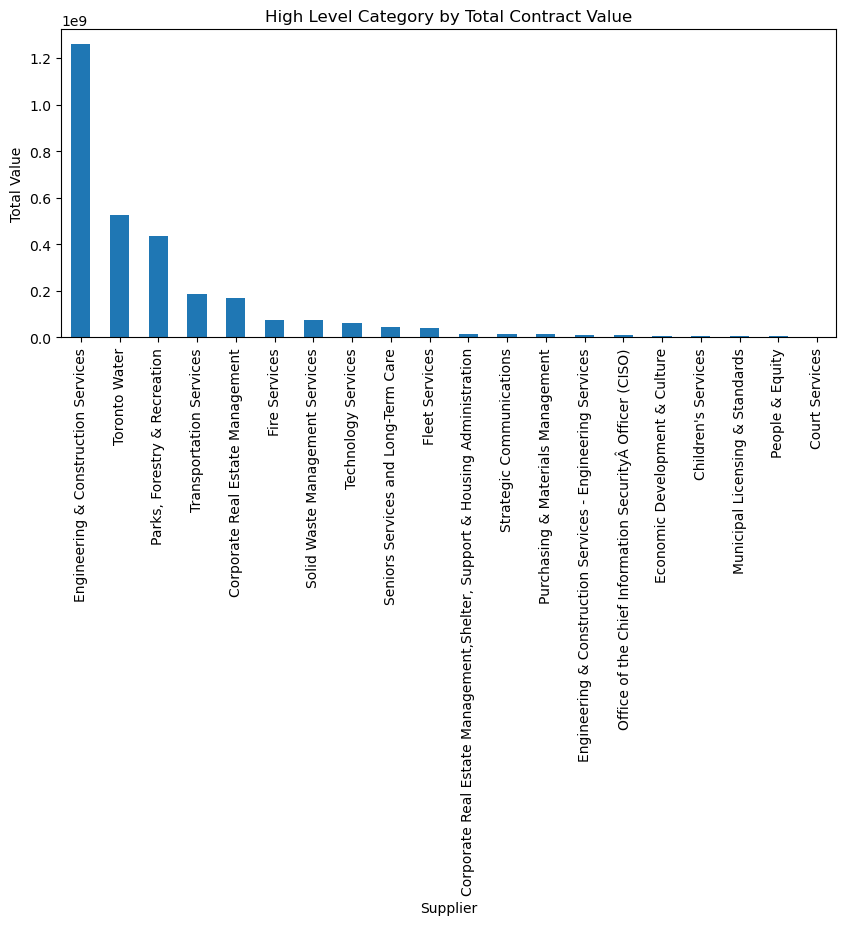

In [25]:
top_suppliers_amount = (
    df_price.groupby("Division")["Awarded Amount"].sum()
    .sort_values(ascending=False)
    .head(20)
)

top_suppliers_amount.plot(kind="bar", figsize=(10,4))
plt.title("High Level Category by Total Contract Value")
plt.xlabel("Supplier")
plt.ylabel("Total Value")
plt.show()

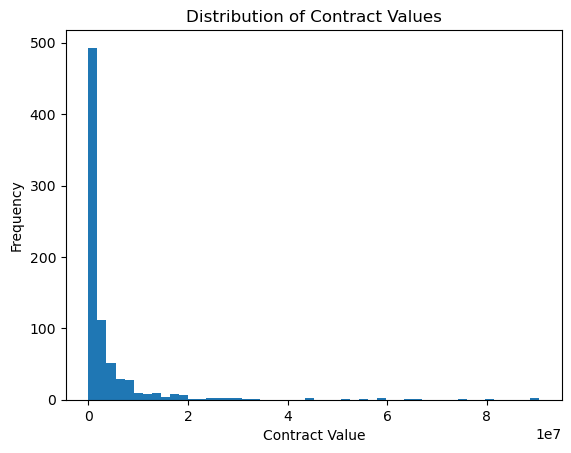

In [26]:
df_price["Awarded Amount"].plot(kind="hist", bins=50)
plt.title("Distribution of Contract Values")
plt.xlabel("Contract Value")
plt.ylabel("Frequency")
plt.show()


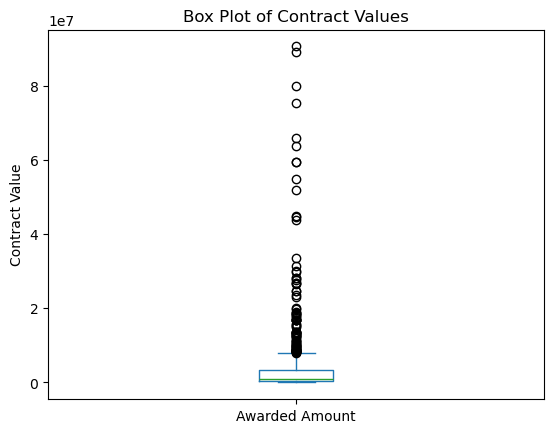

In [27]:
df_price["Awarded Amount"].plot(kind="box")
plt.title("Box Plot of Contract Values")
plt.ylabel("Contract Value")
plt.show()

C:\Users\jcp_2\AppData\Local\Temp\ipykernel_31380\2310612865.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_price["YearMonth"] = df_price["Award Date"].dt.to_period("M").dt.to_timestamp()


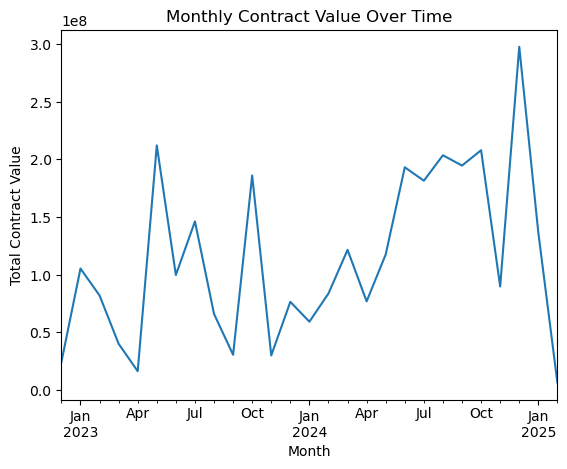

In [28]:
df_price["YearMonth"] = df_price["Award Date"].dt.to_period("M").dt.to_timestamp()

monthly_trend = df_price.groupby("YearMonth")["Awarded Amount"].sum()

monthly_trend.plot(kind="line")
plt.title("Monthly Contract Value Over Time")
plt.xlabel("Month")
plt.ylabel("Total Contract Value")
plt.show()


C:\Users\jcp_2\AppData\Local\Temp\ipykernel_31380\2809835211.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_price


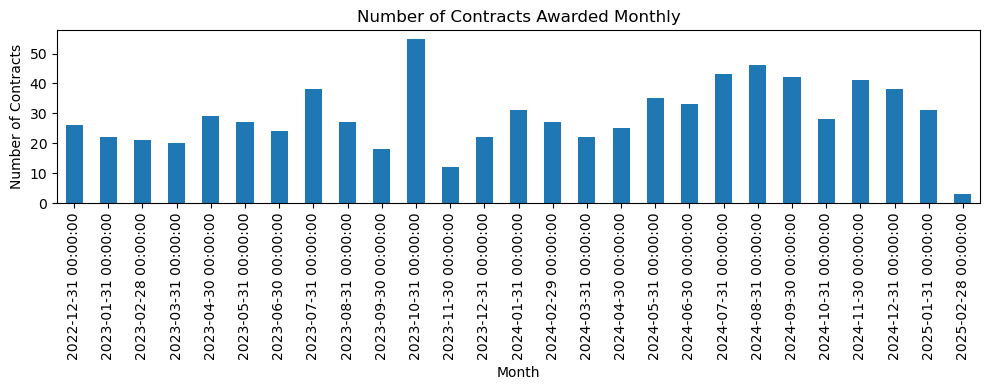

In [29]:
monthly_awraded_contracts = (
    df_price
    .resample('M', on="YearMonth")
    .size()
)

   

monthly_awraded_contracts.plot(kind="bar",figsize=(10,4))
plt.title('Number of Contracts Awarded Monthly')
plt.xlabel('Month')
plt.ylabel('Number of Contracts')
plt.tight_layout()
plt.show()

In [30]:
#df_price.to_csv("./clean_data.csv", index = False)